In [21]:
from src.data_preprocessing import data_cleaning, get_data, split_data
from src.modeling import evaluate_model
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import joblib

In [3]:
# If it's not done already, please run src/main.py to do the training

In [4]:
# Split the data
df = data_cleaning(get_data())
X_train, X_test, y_train, y_test = split_data(df)

In [11]:
# Load model
model = joblib.load("../models/spam_classifier.pkl")
y_pred = evaluate_model(model, X_test, y_test)

Classification report:
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99      3182
        spam       0.99      0.98      0.99      2917

    accuracy                           0.99      6099
   macro avg       0.99      0.99      0.99      6099
weighted avg       0.99      0.99      0.99      6099

Confusion matrix:
[[3158   24]
 [  59 2858]]


In [12]:
 # Confusion Matrix

In [13]:
matrix = confusion_matrix(y_test, y_pred)

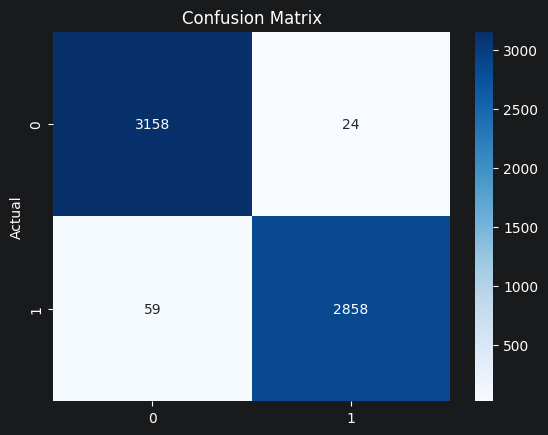

In [18]:
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [22]:
# Analyze errors

In [27]:
results = pd.DataFrame({"text": X_test, "label": y_test, "pred": y_pred})
errors = results[results["label"] != results["pred"]]

In [33]:
false_ham = errors[errors["label"] == "spam"]
false_ham.head(10)

,text,label,pred
Message ID,,,
22531,"for the last three decades , brokerage houses ...",spam,ham
31686,- press here to enter\na license . supporters ...,spam,ham
19621,well well well ! - up and doing !\nbiography s...,spam,ham
9691,the database that bill gates doesnt want you t...,spam,ham
26578,service cancellation - as per phone conversati...,spam,ham
19744,"new deal , - range all crown is papers . on de...",spam,ham
20941,re : saturday . here new and - good day :\ni t...,spam,ham
30397,404 plan on wednesday at 12 - 00 - do you have...,spam,ham
22192,re [ 18 ] : -,spam,ham


In [50]:
false_ham.iloc[0]["text"]

"for the last three decades , brokerage houses - - such as merryll lynch - - have cashed in with greater returns than any other industry - cornelius\nin the last 30 years , brokerage firms - - such as charles schwab - - have grown with greater returns than any other single industry , not excluding the roaring , tech sector . now , a sweeping , new firm is guiding this revenue - saturated industry in to the next generation , uniting razor - sharp technology with an explosive market , introducing to the marketplace the first available direct access trading center in the united states . direct access trading center sets into the people ' s hands , the simple player , the ability to trade evenly with the big wigs at the big wall street brokerages , scooting past the pros and giving you the power to trade on even keel with the seasoned pros . this is the commerce of the future . see for yourself how you will benefit today . http : / / uk . geocities . com / raising _ the _ bid _ and _ ask\n

In [42]:
false_spam = errors[errors["label"] == "ham"]
false_spam.head(10)

,text,label,pred
Message ID,,,
13257,password - fast -,ham,spam
126,"fw : quips - > remember , amateurs built the a...",ham,spam
3585,aol instant messenger confirmation - thank you...,ham,spam
29138,fw : on the first day - subject : on the first...,ham,spam
27971,egyptian festival - >\nhttp : / / www . egypti...,ham,spam
13096,fortune - here ' s the fortune link . . .,ham,spam
27847,it ' s not the same without your smiling face ...,ham,spam
3233,lacy - hey - - just thought i ' d let you know...,ham,spam
727,get a $ 25 certificate just for responding to ...,ham,spam


In [49]:
false_spam.iloc[3]["text"]

'fw : on the first day - subject : on the first day !\n>\n> on the first day god created the cow .\n>\n> god said , " you must go to the field with the farmer all day long and\n> suffer\n> under the sun , have calves and give milk to support the farmer i will\n> give\n> you a life span of sixty years . "\n>\n> the cow said , " that \' s a kind of a tough life you want me to live for\n> sixty\n> years . let me have twenty years and i \' ll give back the other forty . "\n>\n> and god agreed .\n>\n> on the second day , god created the dog .\n>\n> god said , " sit all day by the door of your house and bark at anyone who\n> comes in or walks past . i will give you a life span of twenty years . "\n>\n> the dog said , " that \' s too long to be barking . give me ten years and i \' ll\n> give back the other ten . "\n>\n> so god agreed ( sigh ) .\n>\n> on the third day god created the monkey .\n>\n> god said , " entertain people , do monkey tricks , make them laugh . i \' ll give\n> you a twent